In [1]:
import cv2
import os
import tensorflow as tf
from tensorflow import keras
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from keras.utils import normalize
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
from keras.utils import to_categorical
from keras.models import load_model
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [2]:
image_directory='datasets/'

no_tumor_images=os.listdir(image_directory+ 'no/')
yes_tumor_images=os.listdir(image_directory+ 'yes/')
dataset=[]
label=[]

INPUT_SIZE=64

In [3]:
for i , image_name in enumerate(no_tumor_images):
    if(image_name.split('.')[1]=='jpg'):
        image=cv2.imread(image_directory+'no/'+image_name)
        image=Image.fromarray(image,'RGB')
        image=image.resize((INPUT_SIZE,INPUT_SIZE))
        dataset.append(np.array(image))
        label.append(0)

In [4]:
for i , image_name in enumerate(yes_tumor_images):
    if(image_name.split('.')[1]=='jpg'):
        image=cv2.imread(image_directory+'yes/'+image_name)
        image=Image.fromarray(image, 'RGB')
        image=image.resize((INPUT_SIZE,INPUT_SIZE))
        dataset.append(np.array(image))
        label.append(1)

In [5]:
dataset=np.array(dataset)
label=np.array(label)

In [6]:
print(dataset.shape)
print(label.shape)

(3000, 64, 64, 3)
(3000,)


In [7]:
x_train, x_test, y_train, y_test=train_test_split(dataset, label, test_size=0.2, random_state=0)



print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

x_train=normalize(x_train, axis=1)
x_test=normalize(x_test, axis=1)




(2400, 64, 64, 3)
(2400,)
(600, 64, 64, 3)
(600,)


In [11]:
print(x_train.min(), x_train.max())  

0.0 1.0


In [12]:
model=Sequential()

model.add(Conv2D(32, (3,3), input_shape=(INPUT_SIZE, INPUT_SIZE, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, (3,3), kernel_initializer='he_uniform'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(64, (3,3), kernel_initializer='he_uniform'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 29, 29, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 176,225 (688.38 KB)

 Trainable params: 176,225 (688.38 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [16]:


history = model.fit(
    x_train, 
    y_train, 
    batch_size=16, 
    verbose=1, 
    epochs=10, 
    validation_data=(x_test, y_test),
    shuffle=True
)





Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.6550 - loss: 0.6103 - val_accuracy: 0.7700 - val_loss: 0.4799
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8179 - loss: 0.4265 - val_accuracy: 0.7933 - val_loss: 0.4169
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8655 - loss: 0.3167 - val_accuracy: 0.8900 - val_loss: 0.2724
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9024 - loss: 0.2478 - val_accuracy: 0.8850 - val_loss: 0.2617
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9279 - loss: 0.1817 - val_accuracy: 0.9367 - val_loss: 0.1672
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9548 - loss: 0.1374 - val_accuracy: 0.9633 - val_loss: 0.1124
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9761 - loss: 0.0809 - val_accuracy: 0.9717 - val_loss: 0.0935
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9910 - loss: 0.0466 - val_acc

In [48]:
model.save('newmodel.h5')

In [17]:
model.evaluate(x_test,y_test)[1]*100

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9883 - loss: 0.0472


98.33333492279053

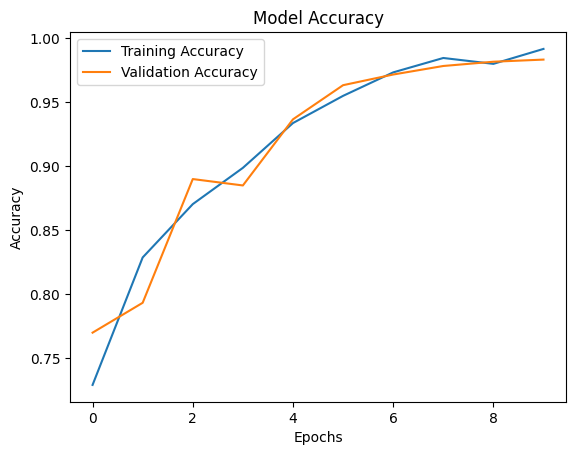

In [18]:

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()





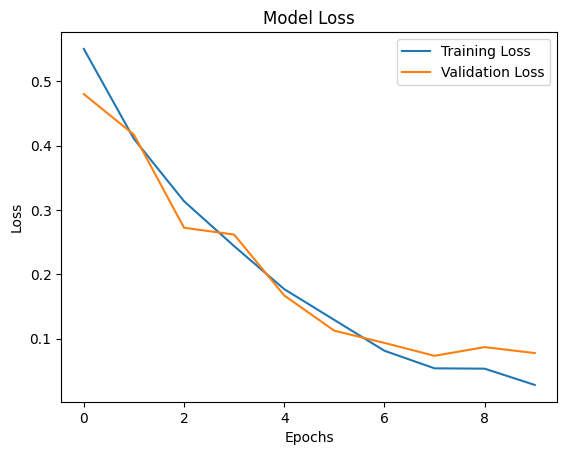

In [19]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [47]:
model=load_model('newmodel.h5')

image=cv2.imread('D:\\btnew\\testimagess\\no\\n2.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image1=cv2.imread('D:\\btnew\\testimagess\\yes\\y3.jpg')
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
img=Image.fromarray(image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
[[0]]


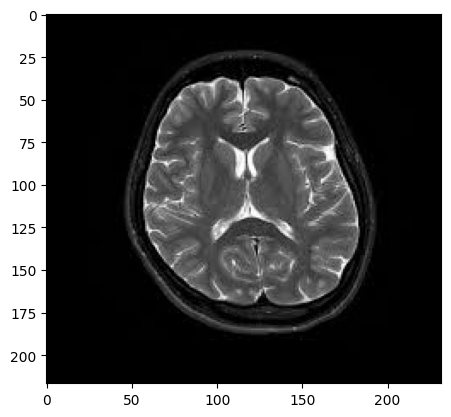

In [44]:
plt.imshow(image)
img=img.resize((64,64))

img=np.array(img)

input_img=np.expand_dims(img, axis=0)

predictions = model.predict(input_img) 
result = (predictions > 0.5).astype(int)  
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[1]]


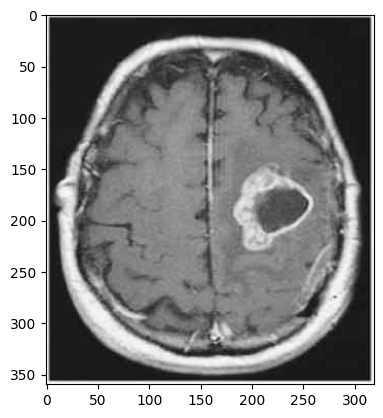

In [45]:
plt.imshow(image1)
img1=Image.fromarray(image1)

img1=img1.resize((64,64))

img1=np.array(img1)


input_img1=np.expand_dims(img1, axis=0)

predictions1 = model.predict(input_img1)  # Get class probabilities
result1 = (predictions1 > 0.5).astype(int)  # Threshold at 0.5
print(result1)



